In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sys.path.append('./modules')
df = pd.read_csv('../data/01-interim/epcg23_interim_cleaned.csv', low_memory = False)

In [2]:
## Load EDA1 DF + Filter 
df_eda1 = df.copy()

label_map = {
    1: 'Computer/Math Science',
    2: 'Bio/Agricultural/Life Science',
    3: 'Physical & Related Science',
    4: 'Social & Related Science',
    5: 'Engineering',
    6: 'Science & Engineering Related',
    7: 'Non-Science & Engineering'
}

# Filter out Logical Skip and apply
df_eda1 = df_eda1[df_eda1['NBAMEMG'] < 8]
df_eda1 = df_eda1[df_eda1['N2OCPRMG'] < 8]
df_eda1['Major_Category'] = df_eda1['NBAMEMG'].map(label_map)
df_eda1['Job_Category'] = df_eda1['N2OCPRMG'].map(label_map)

In [3]:
## Load EDA4 + Map
df_eda4 = df.copy()
df_eda4['NBAMEMG'] = pd.to_numeric(df_eda4['NBAMEMG'], errors='coerce')
df_eda4['EMSMI'] = pd.to_numeric(df_eda4['EMSMI'], errors='coerce')
df_eda4 = df_eda4[df_eda4['NBAMEMG'].notna() & df_eda4['EMSMI'].notna()].copy()
df_eda4['NBAMEMG'] = df_eda4['NBAMEMG'].astype(int)
df_eda4['EMSMI'] = df_eda4['EMSMI'].astype(int)

## Reuse label_map from EDA1 for major
employment_dict = {
    1: 'Same employer & same job', 
    2: 'Same employer BUT diff job',
    3: 'Diff employer BUT same job', 
    4: 'Diff employer & diff job'
}

df_eda4['Major_Category'] = df_eda4['NBAMEMG'].map(label_map)
df_eda4['Employment_Status'] = df_eda4['EMSMI'].map(employment_dict)
df_eda4 = df_eda4[df_eda4['Major_Category'].notna() & df_eda4['Employment_Status'].notna()].copy()

In [5]:
# STATISTICAL TESTING: Chi-Square
# Frequency contingency table with raw counts
contingency_table = pd.crosstab(
    df_eda4['NBAMEMG'], 
    df_eda4['EMSMI']
)
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p}")
print("Conclusion: Statistically significant relationship exists (p < 0.05).")


--- Chi-Square Test Results ---
Chi-Square Statistic: 276.03
P-value: 3.981263325354591e-48
Conclusion: Statistically significant relationship exists (p < 0.05).


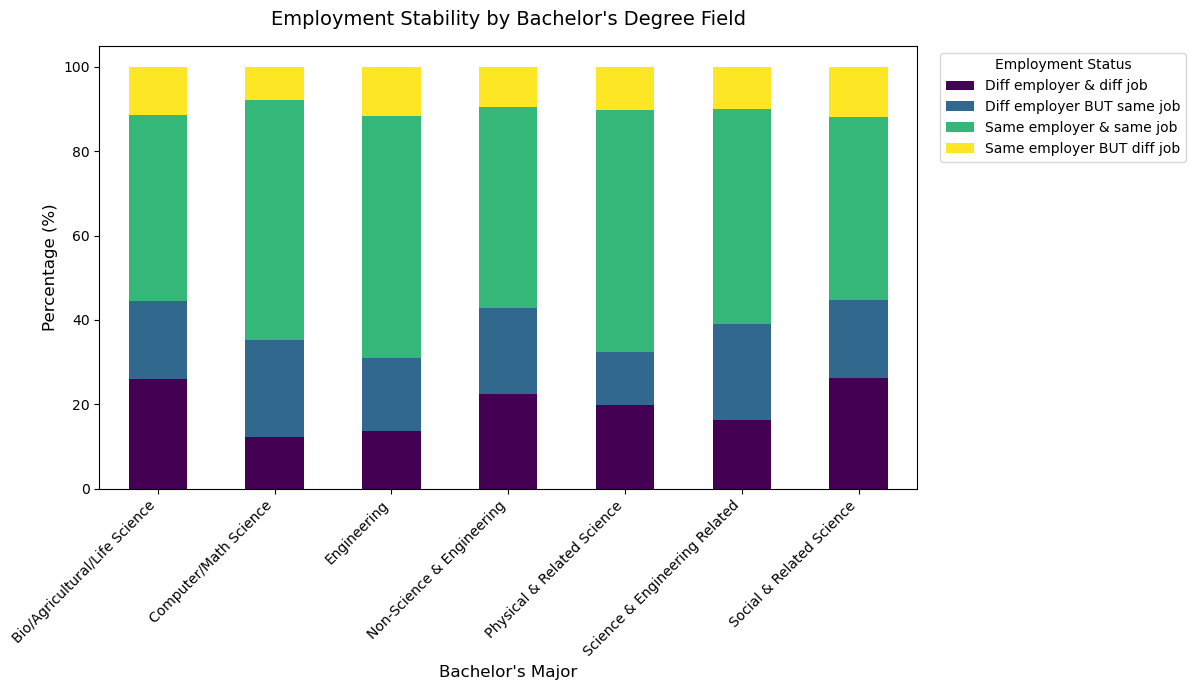

In [6]:
## EDA4 Plot:
# VISUALIZATION: 100% Stacked Bar Chart
crosstab_pct = pd.crosstab(
    df_eda4['Major_Category'], 
    df_eda4['Employment_Status'], 
    normalize='index'
) * 100

ax = crosstab_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    colormap='viridis'
)

plt.title('Employment Stability by Bachelor\'s Degree Field', fontsize=14, pad=15)
plt.xlabel('Bachelor\'s Major', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Employment Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout() 
os.makedirs('../results/EDA4_figs', exist_ok=True)
plt.savefig('../results/EDA4_figs/employment-stability-major.png', dpi=150, bbox_inches='tight')
plt.show()